In [1]:
from src.config import RAW_DATA_DIR

from src.data.loader import load_meld

from src.features.tfidf import TFIDFFeatures

from src.models.svm import LinearSVMClassifier

from src.evaluation.metrics import (
    evaluate,
    print_results,
    plot_confusion_matrix,
)

In [7]:
from src.evaluation.results import (
    save_metrics,
    save_metadata,
    save_confusion_matrix,
)

In [2]:
meld = load_meld(RAW_DATA_DIR / "meld")

In [3]:
features = TFIDFFeatures()

X_train = features.fit_transform(meld.train["text"])
X_test = features.transform(meld.test["text"])

y_train = meld.train["emotion"]
y_test = meld.test["emotion"]

In [4]:
model = LinearSVMClassifier()

model.fit(
    X_train,
    y_train,
)


===== EVALUATION =====
Accuracy     : 0.5057
Macro F1     : 0.2788
Weighted F1  : 0.4596

Per-class metrics
--------------------------------------------------
Emotion        Precision      Recall          F1
anger             0.2699      0.1275      0.1732
disgust           0.3333      0.1176      0.1739
fear              0.0000      0.0000      0.0000
joy               0.4058      0.2786      0.3304
neutral           0.5691      0.8033      0.6662
sadness           0.2941      0.1202      0.1706
surprise          0.4404      0.4342      0.4373

Confusion Matrix
[[  44    5    3   33  205   12   43]
 [   8    8    1    5   33    3   10]
 [   6    1    0    3   33    5    2]
 [  20    2    1  112  239    9   19]
 [  57    6    4   87 1009   24   69]
 [  15    1    3   24  128   25   12]
 [  13    1    0   12  126    7  122]]


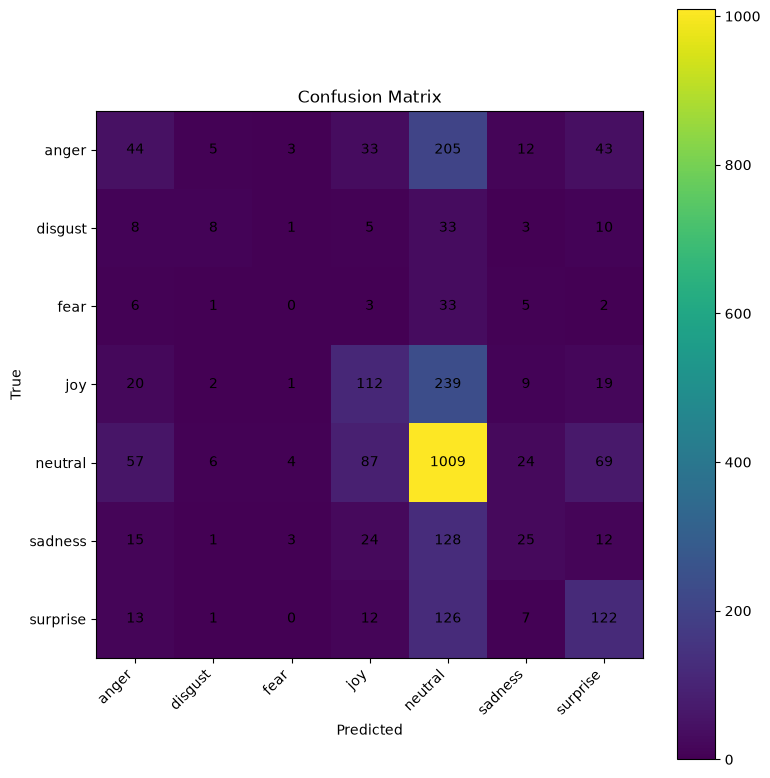

In [5]:
pred = model.predict(X_test)

results = evaluate(
    y_test,
    pred,
)

print_results(results)

plot_confusion_matrix(results)

In [8]:
save_metrics(
    results,
    "svm_unigram",
)

save_metadata(
    "svm_unigram",
    model="Linear SVM",
    dataset="MELD",
    ngram_range=(1, 1),
    max_features=None,
    min_df=1,
    max_df=1.0,
)

save_confusion_matrix(
    results,
    "svm_unigram",
)